<a href="https://colab.research.google.com/github/JannatLima/earthquake-blast-classification-ml/blob/main/earthquake_blast_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#-------Cell 1---------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [2]:
#-------Cell 2---------#
#-----Retrieve quarry blast events from USGS-----#

qb_url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query?"
    "format=csv"
    "&starttime=2000-01-01"
    "&endtime=2024-12-31"
    "&minmagnitude=1.0"
    "&maxmagnitude=4.5"
    "&eventtype=quarry%20blast"
    "&limit=20000"
)

quarry_df = pd.read_csv(qb_url)

quarry_df['Type'] = 'Quarry Blast'

print("Quarry blast events retrieved:", len(quarry_df))
print("\nColumns:")
print(quarry_df.columns.tolist())

print("\nDate range:")
print(quarry_df['time'].min(), "to", quarry_df['time'].max())


Quarry blast events retrieved: 20000

Columns:
['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource', 'Type']

Date range:
2004-02-03T19:57:42.720Z to 2024-12-30T21:59:10.160Z


In [3]:
#-------Cell 3A---------#
#-----Audit quarry-blast yearly distribution-----#

quarry_df['event_year'] = pd.to_datetime(
    quarry_df['time'], utc=True
).dt.year

print("Quarry blasts by year:")
print(quarry_df['event_year'].value_counts().sort_index())

print("\nTotal:")
print(len(quarry_df))

print("\nYear range:")
print(quarry_df['event_year'].min(), "to", quarry_df['event_year'].max())

Quarry blasts by year:
event_year
2004     779
2005     851
2006     861
2007     933
2008     945
2009     711
2010     680
2011     730
2012     787
2013     821
2014     697
2015     947
2016    1061
2017    1014
2018     938
2019     987
2020    1137
2021    1404
2022    1202
2023    1166
2024    1349
Name: count, dtype: int64

Total:
20000

Year range:
2004 to 2024


In [7]:
#-------Cell 3---------#
#-----Retrieve and reproducibly sample earthquake events-----#

import time

RANDOM_SEED = 42
EQ_PER_YEAR = 800

years = list(range(2000, 2025))

eq_frames = []

for year in years:

    url = (
        f"https://earthquake.usgs.gov/fdsnws/event/1/query?"
        f"format=csv"
        f"&starttime={year}-01-01"
        f"&endtime={year}-12-31"
        f"&minmagnitude=1.0"
        f"&maxmagnitude=4.5"
        f"&eventtype=earthquake"
        f"&limit=20000"
    )

    try:
        chunk = pd.read_csv(url)

        print(f"{year}: {len(chunk)} qualifying earthquakes retrieved")

        # Reproducible random sampling within each year
        if len(chunk) >= EQ_PER_YEAR:
            chunk = chunk.sample(
                n=EQ_PER_YEAR,
                random_state=RANDOM_SEED
            )
        else:
            print(
                f"WARNING: {year} has only {len(chunk)} "
                f"qualifying earthquakes."
            )

        eq_frames.append(chunk)

        print(f"{year}: {len(chunk)} selected")

    except Exception as e:
        print(f"{year}: failed ({e})")

    time.sleep(1)  # Be polite to the USGS server


earthquake_df = pd.concat(eq_frames, ignore_index=True)

earthquake_df['Type'] = 'Earthquake'

print("\n" + "=" * 60)
print("Earthquake sampling completed")
print("=" * 60)

print("Total earthquake events selected:", len(earthquake_df))

print("\nEvents by year:")
print(
    pd.to_datetime(
        earthquake_df['time'],
        utc=True
    ).dt.year.value_counts().sort_index()
)

2000: 20000 qualifying earthquakes retrieved
2000: 800 selected
2001: 20000 qualifying earthquakes retrieved
2001: 800 selected
2002: 20000 qualifying earthquakes retrieved
2002: 800 selected
2003: 20000 qualifying earthquakes retrieved
2003: 800 selected
2004: 20000 qualifying earthquakes retrieved
2004: 800 selected
2005: 20000 qualifying earthquakes retrieved
2005: 800 selected
2006: 20000 qualifying earthquakes retrieved
2006: 800 selected
2007: 20000 qualifying earthquakes retrieved
2007: 800 selected
2008: 20000 qualifying earthquakes retrieved
2008: 800 selected
2009: 20000 qualifying earthquakes retrieved
2009: 800 selected
2010: 20000 qualifying earthquakes retrieved
2010: 800 selected
2011: 20000 qualifying earthquakes retrieved
2011: 800 selected
2012: 20000 qualifying earthquakes retrieved
2012: 800 selected
2013: 20000 qualifying earthquakes retrieved
2013: 800 selected
2014: 20000 qualifying earthquakes retrieved
2014: 800 selected
2015: 20000 qualifying earthquakes retri

In [8]:
#-------Cell 4---------#
#-----Combine final sampled dataset-----#

df = pd.concat(
    [quarry_df, earthquake_df],
    ignore_index=True
)

print("=" * 60)
print("FINAL DATASET")
print("=" * 60)

print("\nClass distribution:")
print(df['Type'].value_counts())

print("\nTotal events:", len(df))

print("\nDate range:")
print(df['time'].min(), "to", df['time'].max())

print("\nEvents by year and class:")

df['event_year'] = pd.to_datetime(
    df['time'],
    utc=True
).dt.year

print(
    pd.crosstab(
        df['event_year'],
        df['Type']
    ).to_string()
)

print("\nDataset shape:", df.shape)

FINAL DATASET

Class distribution:
Type
Quarry Blast    20000
Earthquake      20000
Name: count, dtype: int64

Total events: 40000

Date range:
2000-08-18T09:20:38.380Z to 2024-12-30T21:59:10.160Z

Events by year and class:
Type        Earthquake  Quarry Blast
event_year                          
2000               800             0
2001               800             0
2002               800             0
2003               800             0
2004               800           784
2005               800           851
2006               800           861
2007               800           933
2008               800           945
2009               800           711
2010               800           680
2011               800           730
2012               800           787
2013               800           821
2014               800           697
2015               800           947
2016               800          1061
2017               800          1014
2018               800           938

In [9]:
#-------Cell 5---------#
physical_cols = [
    'latitude',
    'longitude',
    'depth',
    'mag',
    'nst',
    'gap',
    'dmin',
    'rms',
    'horizontalError',
    'depthError',
    'magError',
    'magNst'
]

df_physical = df[[c for c in physical_cols + ['Type'] if c in df.columns]].copy()

print("Dataset shape:", df_physical.shape)
print("\nClass distribution:")
print(df_physical['Type'].value_counts())

print("\nMissing values:")
print(df_physical.isnull().sum())

Dataset shape: (40000, 13)

Class distribution:
Type
Quarry Blast    20000
Earthquake      20000
Name: count, dtype: int64

Missing values:
latitude               0
longitude              0
depth                  0
mag                    0
nst                 7796
gap                 7181
dmin               10333
rms                 1303
horizontalError    11886
depthError          2062
magError           10854
magNst              8606
Type                   0
dtype: int64


In [10]:
#-------Cell 6---------#
X_raw = df_physical.drop('Type', axis=1)
y_raw = df_physical['Type']

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y))

Classes: ['Earthquake' 'Quarry Blast']
Encoded classes: [0 1]


In [11]:
#-------Cell 7---------#
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_raw))
print("Testing samples :", len(X_test_raw))

Training samples: 32000
Testing samples : 8000


In [12]:
#-------Cell 8---------#
train_medians = X_train_raw.median(numeric_only=True)

X_train_imputed = X_train_raw.fillna(train_medians)
X_test_imputed = X_test_raw.fillna(train_medians)  # same values from train, never test

print("Remaining missing values in train:", X_train_imputed.isnull().sum().sum())
print("Remaining missing values in test:", X_test_imputed.isnull().sum().sum())

Remaining missing values in train: 0
Remaining missing values in test: 0


In [13]:
#-------Cell 9---------#
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_imputed)
X_test = scaler.transform(X_test_imputed)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (32000, 12)
X_test shape : (8000, 12)


In [14]:
#-------Cell 10---------#
rf_physical = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_physical.fit(X_train, y_train)

rf_pred = rf_physical.predict(X_test)
rf_prob = rf_physical.predict_proba(X_test)[:, 1]

print("=" * 60)
print("RANDOM FOREST — PHYSICAL FEATURES ONLY (leakage-safe)")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall   : {recall_score(y_test, rf_pred):.4f}")
print(f"F1-score : {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

RANDOM FOREST — PHYSICAL FEATURES ONLY (leakage-safe)
Accuracy : 0.9926
Precision: 0.9935
Recall   : 0.9918
F1-score : 0.9926
ROC-AUC  : 0.9995

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      0.99      0.99      4000
Quarry Blast       0.99      0.99      0.99      4000

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000


Confusion Matrix:
[[3974   26]
 [  33 3967]]


In [15]:
#-------Cell 11---------#
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,658 (10.38 KB)

 Trainable params: 2,658 (10.38 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#-------Cell 12---------#
monitor = EarlyStopping(monitor='val_loss', patience=5, verbose=1,
                         mode='min', restore_best_weights=True)

checkpoint = ModelCheckpoint('./best_weights_physical.keras', monitor='val_loss',
                              mode='min', save_best_only=True, verbose=1)

reduceLR = ReduceLROnPlateau()
callback_list = [monitor, checkpoint, reduceLR]

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
#-------Cell 13---------#
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:", class_weight_dict)

history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    batch_size=32,
    epochs=50,
    callbacks=callback_list,
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Epoch 1/50
787/800 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8174 - loss: 0.3830
Epoch 1: val_loss improved from None to 0.10680, saving model to ./best_weights_physical.keras

Epoch 1: finished saving model to ./best_weights_physical.keras
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9062 - loss: 0.2607 - val_accuracy: 0.9609 - val_loss: 0.1068 - learning_rate: 0.0010
Epoch 2/50
791/800 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9619 - loss: 0.1385
Epoch 2: val_loss did not improve from 0.10680
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9638 - loss: 0.1296 - val_accuracy: 0.9581 - val_loss: 0.1079 - learning_rate: 0.0010
Epoch 3/50
791/800 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9662 - loss: 0.0915
Epoch 3: val_loss improved from 0.10680 to 0.08435, saving model to ./best_weights_physical.keras

Epoch 3: finished saving model to ./best_weights_physical.keras
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1m

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9805 - loss: 0.0572
Neural Network Test Accuracy: 0.9805
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 704us/step

Classification Report (Neural Network, physical features only):
              precision    recall  f1-score   support

  Earthquake       0.98      0.98      0.98      4000
Quarry Blast       0.98      0.98      0.98      4000

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000



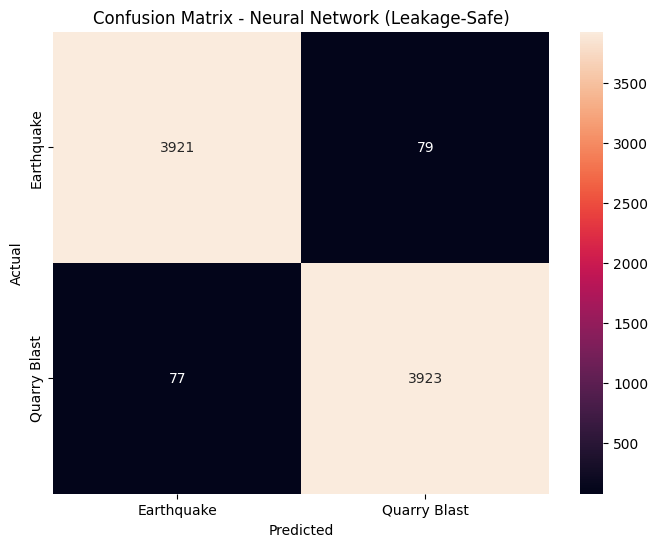

In [18]:
#-------Cell 14---------#
test_loss, test_acc_nn = model.evaluate(X_test, y_test_cat)
print(f"Neural Network Test Accuracy: {test_acc_nn:.4f}")

y_pred_probs = model.predict(X_test)
y_pred_nn = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report (Neural Network, physical features only):")
print(classification_report(y_test, y_pred_nn, target_names=label_encoder.classes_))

cf_matrix = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cf_matrix, annot=True, fmt="d",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Neural Network (Leakage-Safe)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

            Feature  Importance
2             depth    0.462766
9        depthError    0.229473
1         longitude    0.110901
0          latitude    0.079979
3               mag    0.037966
7               rms    0.019731
6              dmin    0.019520
8   horizontalError    0.010344
11           magNst    0.009312
10         magError    0.009227
5               gap    0.005460
4               nst    0.005322


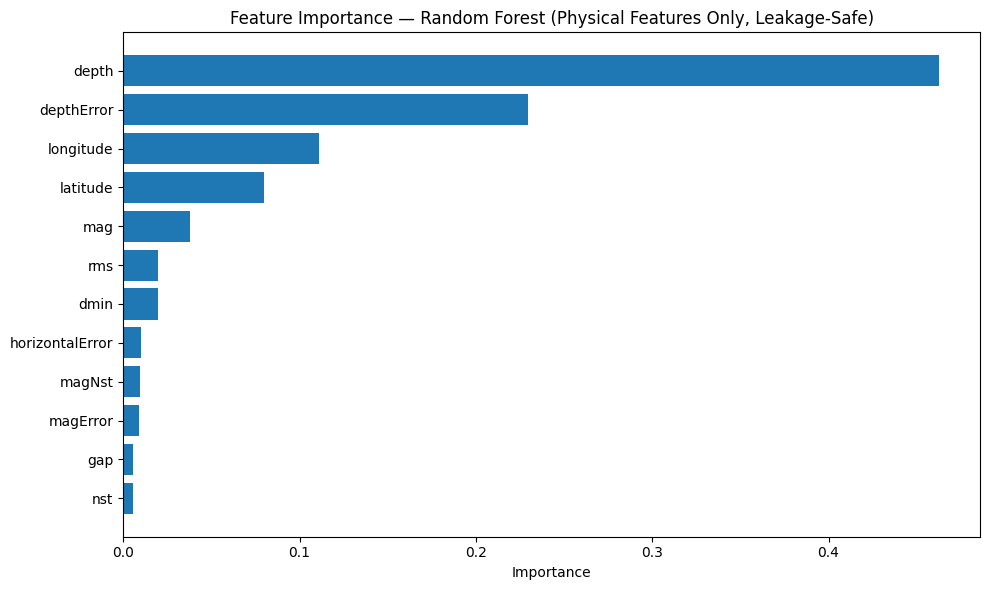

In [19]:
#-------Cell 15---------#
feature_names = X_raw.columns.tolist()
importances = rf_physical.feature_importances_

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feat_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance_df['Feature'], feat_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance — Random Forest (Physical Features Only, Leakage-Safe)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
#-------Cell 16---------#
print("depthError statistics by event type:\n")
print(df_physical.groupby('Type')['depthError'].describe())

print("\nMost common depthError values per type:")
print("\nQuarry Blast top values:")
print(df_physical[df_physical['Type'] == 'Quarry Blast']['depthError'].value_counts().head(10))
print("\nEarthquake top values:")
print(df_physical[df_physical['Type'] == 'Earthquake']['depthError'].value_counts().head(10))

depthError statistics by event type:

                count       mean         std   min    25%    50%    75%  \
Type                                                                      
Earthquake    17938.0   5.074179  215.360306  0.00   0.39   0.74   2.00   
Quarry Blast  20000.0  25.754557   11.979645  0.12  31.61  31.61  31.61   

                  max  
Type                   
Earthquake    28652.5  
Quarry Blast    236.1  

Most common depthError values per type:

Quarry Blast top values:
depthError
31.61    15984
0.60       319
0.50       315
0.70       220
0.40       216
0.80       170
0.90       105
0.30        81
1.00        78
1.10        40
Name: count, dtype: int64

Earthquake top values:
depthError
0.2    918
0.3    886
0.4    768
0.1    647
0.5    593
0.0    565
0.6    504
0.7    374
0.8    289
0.9    242
Name: count, dtype: int64


In [21]:
#-------Cell 17---------#
physical_cols_clean = [c for c in physical_cols if c != 'depthError']

X_raw_clean = df_physical[physical_cols_clean]

X_train_raw_clean, X_test_raw_clean, y_train_c, y_test_c = train_test_split(
    X_raw_clean, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

train_medians_clean = X_train_raw_clean.median(numeric_only=True)
X_train_imp_clean = X_train_raw_clean.fillna(train_medians_clean)
X_test_imp_clean = X_test_raw_clean.fillna(train_medians_clean)

scaler_clean = StandardScaler()
X_train_clean = scaler_clean.fit_transform(X_train_imp_clean).astype(np.float32)
X_test_clean = scaler_clean.transform(X_test_imp_clean).astype(np.float32)

rf_clean = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_clean.fit(X_train_clean, y_train_c)
rf_pred_clean = rf_clean.predict(X_test_clean)

print(f"Accuracy without depthError: {accuracy_score(y_test_c, rf_pred_clean):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, rf_pred_clean, target_names=label_encoder.classes_))

Accuracy without depthError: 0.9924

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      0.99      0.99      4000
Quarry Blast       0.99      0.99      0.99      4000

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000



            Feature  Importance
2             depth    0.607637
1         longitude    0.128285
0          latitude    0.091879
3               mag    0.060638
7               rms    0.030044
6              dmin    0.020702
8   horizontalError    0.016836
9          magError    0.016279
10           magNst    0.013540
5               gap    0.007089
4               nst    0.007070


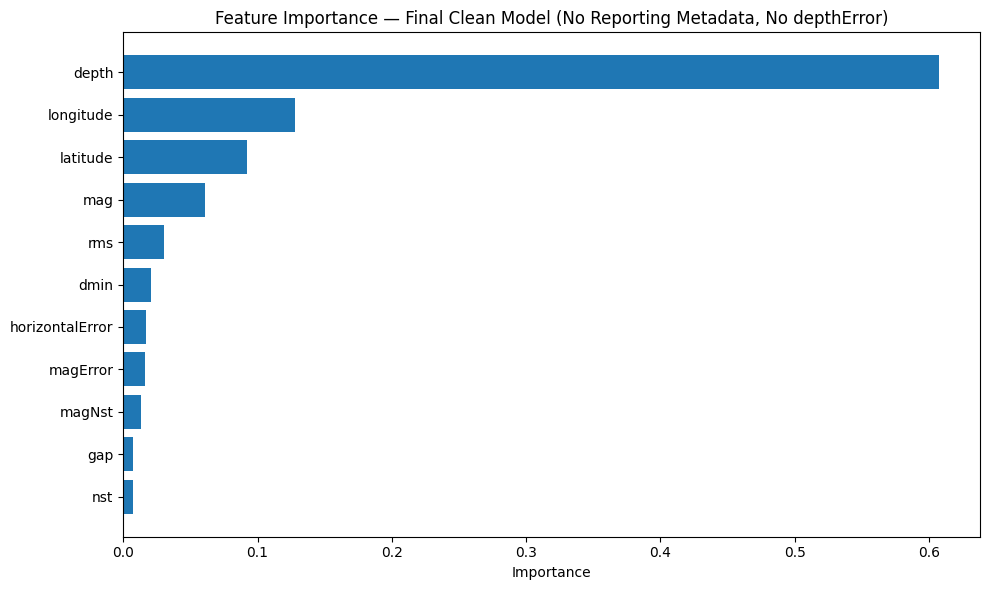

In [22]:
#-------Cell 18---------#
feat_importance_clean = pd.DataFrame({
    'Feature': physical_cols_clean,
    'Importance': rf_clean.feature_importances_
}).sort_values('Importance', ascending=False)

print(feat_importance_clean)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance_clean['Feature'], feat_importance_clean['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance — Final Clean Model (No Reporting Metadata, No depthError)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
#-------Cell 19---------#
y_train_cat_clean = to_categorical(y_train_c, num_classes=2)
y_test_cat_clean = to_categorical(y_test_c, num_classes=2)

model_clean = Sequential()
model_clean.add(Input(shape=(X_train_clean.shape[1],)))
model_clean.add(Dense(32, activation='relu'))
model_clean.add(Dense(64, activation='relu'))
model_clean.add(Dense(2, activation='softmax'))

model_clean.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

monitor_clean = EarlyStopping(monitor='val_loss', patience=5, verbose=1,
                               mode='min', restore_best_weights=True)
reduceLR_clean = ReduceLROnPlateau()

class_weights_clean = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train_c), y=y_train_c
)
class_weight_dict_clean = dict(enumerate(class_weights_clean))

history_clean = model_clean.fit(
    X_train_clean, y_train_cat_clean,
    validation_split=0.2,
    batch_size=32,
    epochs=50,
    callbacks=[monitor_clean, reduceLR_clean],
    class_weight=class_weight_dict_clean,
    verbose=1
)

Epoch 1/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8809 - loss: 0.2854 - val_accuracy: 0.9455 - val_loss: 0.1577 - learning_rate: 0.0010
Epoch 2/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9531 - loss: 0.1308 - val_accuracy: 0.9564 - val_loss: 0.1194 - learning_rate: 0.0010
Epoch 3/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9592 - loss: 0.1164 - val_accuracy: 0.9616 - val_loss: 0.1165 - learning_rate: 0.0010
Epoch 4/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9615 - loss: 0.1118 - val_accuracy: 0.9602 - val_loss: 0.1095 - learning_rate: 0.0010
Epoch 5/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9625 - loss: 0.1071 - val_accuracy: 0.9638 - val_loss: 0.1115 - learning_rate: 0.0010
Epoch 6/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9646 - loss: 0.1036 - val_accuracy: 0.9584 - val_loss: 0.1122 - learning_rate: 0.0010
Epoch 7/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9648 - loss: 0.1005 - 

In [24]:
#-------Cell 20---------#
test_loss_c, test_acc_nn_clean = model_clean.evaluate(X_test_clean, y_test_cat_clean)
print(f"Neural Network Test Accuracy (final clean): {test_acc_nn_clean:.4f}")

y_pred_probs_clean = model_clean.predict(X_test_clean)
y_pred_nn_clean = np.argmax(y_pred_probs_clean, axis=1)

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_nn_clean, target_names=label_encoder.classes_))

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9776 - loss: 0.0656
Neural Network Test Accuracy (final clean): 0.9776
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.98      0.98      0.98      4000
Quarry Blast       0.98      0.98      0.98      4000

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000



In [25]:
#-------Cell 21---------#
!pip install shap --quiet

import shap

explainer = shap.TreeExplainer(rf_clean)

# SHAP on a sample of the test set (faster than the full 8000 rows)
sample_idx = np.random.choice(X_test_clean.shape[0], 500, replace=False)
X_sample = X_test_clean[sample_idx]

shap_values = explainer.shap_values(X_sample)

print("SHAP values computed. Shape:", np.array(shap_values).shape)

SHAP values computed. Shape: (500, 11, 2)


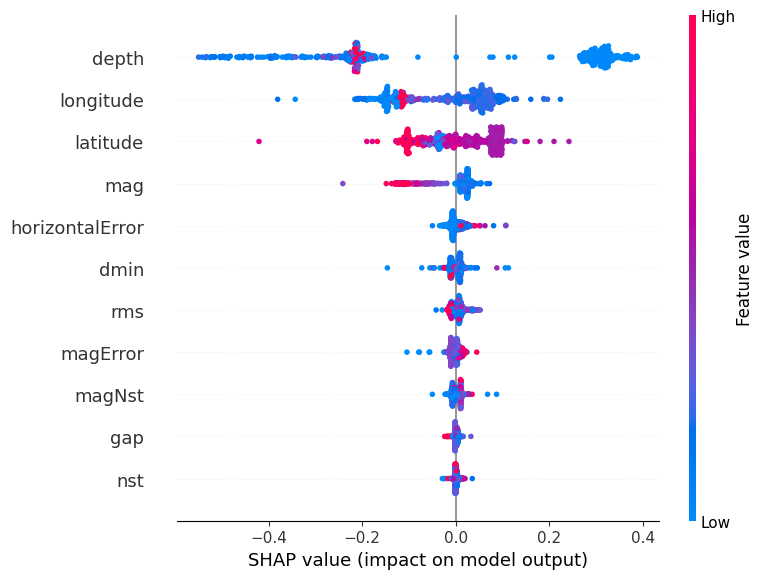

In [26]:
#-------Cell 22---------#
shap.summary_plot(
    shap_values[:, :, 1],  # SHAP values for class 1 (Quarry Blast)
    X_sample,
    feature_names=physical_cols_clean,
    show=True
)

In [27]:
#-------Cell 23---------#
import random

# Fix ALL sources of randomness for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Split ONCE on row indices, before touching any specific feature columns.
# Every experiment below reuses these exact same rows for train/test,
# guaranteed by construction rather than by matching random_state values.
all_indices = df.index.values
y_all = label_encoder.transform(df['Type'])

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all
)

print("Train rows:", len(train_idx))
print("Test rows :", len(test_idx))
print("\nTrain class balance:", pd.Series(y_all[train_idx]).value_counts().to_dict())
print("Test class balance :", pd.Series(y_all[test_idx]).value_counts().to_dict())

Train rows: 32000
Test rows : 8000

Train class balance: {0: 16000, 1: 16000}
Test class balance : {1: 4000, 0: 4000}


In [28]:
#-------Cell 24---------#
#-----Reusable experiment function-----#

def run_experiment(feature_cols, experiment_name,
                   train_idx=train_idx, test_idx=test_idx):

    print(f"\n{'='*60}")
    print(experiment_name)
    print(f"{'='*60}")

    # Select features and target
    data = df[feature_cols + ['Type']].copy()

    X = data[feature_cols]

    # Create labels with explicit DataFrame-index alignment
    y_series = pd.Series(
        label_encoder.transform(df['Type']),
        index=df.index
    )

    # Split using the fixed indices from Cell 23
    X_train = X.loc[train_idx].copy()
    X_test = X.loc[test_idx].copy()

    y_train = y_series.loc[train_idx].values
    y_test = y_series.loc[test_idx].values

    # Identify numeric and categorical features
    categorical_cols = X_train.select_dtypes(
        include=['object', 'category']
    ).columns.tolist()

    numeric_cols = [
        col for col in feature_cols
        if col not in categorical_cols
    ]

    # --------------------------------------------------
    # Missing-value imputation
    # Fit only on training data
    # --------------------------------------------------

    X_train_processed = X_train.copy()
    X_test_processed = X_test.copy()

    # Numeric columns: median imputation
    for col in numeric_cols:
        median_value = X_train_processed[col].median()

        X_train_processed[col] = (
            X_train_processed[col].fillna(median_value)
        )

        X_test_processed[col] = (
            X_test_processed[col].fillna(median_value)
        )

    # Categorical columns: mode imputation
    for col in categorical_cols:
        mode_value = X_train_processed[col].mode()

        if len(mode_value) > 0:
            mode_value = mode_value.iloc[0]
        else:
            mode_value = 'Unknown'

        X_train_processed[col] = (
            X_train_processed[col].fillna(mode_value)
        )

        X_test_processed[col] = (
            X_test_processed[col].fillna(mode_value)
        )

    # --------------------------------------------------
    # One-hot encode categorical features
    # --------------------------------------------------

    X_train_processed = pd.get_dummies(
        X_train_processed,
        columns=categorical_cols,
        drop_first=False
    )

    X_test_processed = pd.get_dummies(
        X_test_processed,
        columns=categorical_cols,
        drop_first=False
    )

    # Make sure test columns exactly match training columns
    X_test_processed = X_test_processed.reindex(
        columns=X_train_processed.columns,
        fill_value=0
    )

    # --------------------------------------------------
    # Scale numeric features
    # Fit scaler only on training data
    # --------------------------------------------------

    scaler = StandardScaler()

    numeric_cols_after_encoding = [
        col for col in numeric_cols
        if col in X_train_processed.columns
    ]

    X_train_processed[numeric_cols_after_encoding] = (
        scaler.fit_transform(
            X_train_processed[numeric_cols_after_encoding]
        )
    )

    X_test_processed[numeric_cols_after_encoding] = (
        scaler.transform(
            X_test_processed[numeric_cols_after_encoding]
        )
    )

    # Convert to NumPy arrays
    X_train_final = X_train_processed.values.astype(np.float32)
    X_test_final = X_test_processed.values.astype(np.float32)

    feature_names_final = X_train_processed.columns.tolist()

    # --------------------------------------------------
    # Random Forest
    # --------------------------------------------------

    rf_model = RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        class_weight='balanced',
        n_jobs=-1
    )

    rf_model.fit(X_train_final, y_train)

    rf_preds = rf_model.predict(X_test_final)

    rf_accuracy = accuracy_score(y_test, rf_preds)

    print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f}")
    print("\nRandom Forest Classification Report:")
    print(
        classification_report(
            y_test,
            rf_preds,
            target_names=label_encoder.classes_
        )
    )

    # --------------------------------------------------
    # Neural Network
    # --------------------------------------------------

    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    nn_model = Sequential([
        Input(shape=(X_train_final.shape[1],)),
        Dense(32, activation='relu'),
        Dense(64, activation='relu'),
        Dense(2, activation='softmax')
    ])

    nn_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Class weights
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weight_dict = dict(
        enumerate(class_weights)
    )

    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    # Train NN
    nn_model.fit(
        X_train_final,
        y_train,
        validation_split=0.2,
        batch_size=32,
        epochs=50,
        callbacks=[early_stopping],
        class_weight=class_weight_dict,
        verbose=0
    )

    # Evaluate NN
    _, nn_accuracy = nn_model.evaluate(
        X_test_final,
        y_test,
        verbose=0
    )

    nn_preds = np.argmax(
        nn_model.predict(X_test_final, verbose=0),
        axis=1
    )

    print(f"\nNeural Network Accuracy: {nn_accuracy:.4f}")
    print("\nNeural Network Classification Report:")
    print(
        classification_report(
            y_test,
            nn_preds,
            target_names=label_encoder.classes_
        )
    )

    # --------------------------------------------------
    # Return all useful results
    # --------------------------------------------------

    return {
        'experiment_name': experiment_name,
        'feature_cols': feature_cols,
        'feature_names_final': feature_names_final,

        'rf_model': rf_model,
        'nn_model': nn_model,

        'X_train': X_train_final,
        'X_test': X_test_final,

        'y_train': y_train,
        'y_test': y_test,

        'rf_preds': rf_preds,
        'nn_preds': nn_preds,

        'rf_accuracy': rf_accuracy,
        'nn_accuracy': nn_accuracy,

        'scaler': scaler
    }

In [29]:
#-------Cell 25---------#
physical_only = [
    'latitude', 'longitude', 'depth', 'mag',
    'nst', 'gap', 'dmin', 'rms',
    'horizontalError', 'depthError', 'magError', 'magNst'
]

physical_plus_metadata = physical_only + ['net', 'status', 'locationSource', 'magSource']

physical_plus_metadata_no_deptherror = [c for c in physical_plus_metadata if c != 'depthError']

results = []
results.append(run_experiment(physical_only, "A: Physical only"))
results.append(run_experiment(physical_plus_metadata, "B: Physical + reporting metadata"))
results.append(run_experiment(physical_plus_metadata_no_deptherror, "C: Physical + metadata, no depthError"))


A: Physical only

Random Forest Accuracy: 0.9926

Random Forest Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      0.99      0.99      4000
Quarry Blast       0.99      0.99      0.99      4000

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000


Neural Network Accuracy: 0.9784

Neural Network Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      0.97      0.98      4000
Quarry Blast       0.97      0.99      0.98      4000

    accuracy                           0.98      8000
   macro avg       0.98      0.98      0.98      8000
weighted avg       0.98      0.98      0.98      8000


B: Physical + reporting metadata

Random Forest Accuracy: 0.9946

Random Forest Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99    

In [30]:
#-------Cell 26---------#
# 1. Exact duplicate rows (identical across all columns)
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")

# 2. Duplicate event IDs (USGS assigns a unique 'id' to every event --
#    if the same id appears twice, we accidentally pulled the same event twice)
id_dupes = df['id'].duplicated().sum()
print(f"Duplicate USGS event IDs: {id_dupes}")

# 3. Near-duplicate events: same time + very close location, possibly
#    the same physical event pulled under both queries (unlikely across
#    types, but worth checking) or duplicated within the same type
#    across overlapping yearly queries.
df['time_rounded'] = pd.to_datetime(df['time']).dt.floor('min')
near_dupes = df.duplicated(subset=['time_rounded', 'latitude', 'longitude', 'Type']).sum()
print(f"Near-duplicate events (same minute, coords, and type): {near_dupes}")

# Show a few examples if any exist
if id_dupes > 0:
    print("\nExample duplicate IDs:")
    print(df[df['id'].duplicated(keep=False)].sort_values('id')[['id', 'time', 'Type']].head(10))

Exact duplicate rows: 0
Duplicate USGS event IDs: 0
Near-duplicate events (same minute, coords, and type): 0


In [31]:
#-------Cell 27---------#
from sklearn.model_selection import StratifiedKFold

physical_only_df = df[physical_only + ['Type']].copy()
X_cv = physical_only_df.drop('Type', axis=1)
y_cv = label_encoder.transform(physical_only_df['Type'])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_cv_scores = []

for fold, (train_i, test_i) in enumerate(skf.split(X_cv, y_cv), 1):
    X_tr, X_te = X_cv.iloc[train_i].copy(), X_cv.iloc[test_i].copy()
    y_tr, y_te = y_cv[train_i], y_cv[test_i]

    medians = X_tr.median()
    X_tr = X_tr.fillna(medians)
    X_te = X_te.fillna(medians)

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr).astype(np.float32)
    X_te_s = sc.transform(X_te).astype(np.float32)

    rf_fold = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                      random_state=SEED, n_jobs=-1)
    rf_fold.fit(X_tr_s, y_tr)
    fold_acc = accuracy_score(y_te, rf_fold.predict(X_te_s))
    rf_cv_scores.append(fold_acc)
    print(f"Fold {fold}: {fold_acc:.4f}")

rf_cv_scores = np.array(rf_cv_scores)
print(f"\nMean accuracy: {rf_cv_scores.mean():.4f}")
print(f"Std deviation: {rf_cv_scores.std():.4f}")

Fold 1: 0.9918
Fold 2: 0.9945
Fold 3: 0.9942
Fold 4: 0.9936
Fold 5: 0.9940

Mean accuracy: 0.9936
Std deviation: 0.0010


In [32]:
#-------Cell 28---------#
df['event_year'] = pd.to_datetime(df['time']).dt.year

train_years_mask = df['event_year'] <= 2019
test_years_mask = df['event_year'] >= 2020

print("Training period (2000-2019) class balance:")
print(df[train_years_mask]['Type'].value_counts())
print("\nTest period (2020-2024) class balance:")
print(df[test_years_mask]['Type'].value_counts())

Training period (2000-2019) class balance:
Type
Earthquake      16000
Quarry Blast    13742
Name: count, dtype: int64

Test period (2020-2024) class balance:
Type
Quarry Blast    6258
Earthquake      4000
Name: count, dtype: int64


In [33]:
#-------Cell 29---------#
train_temporal = df[train_years_mask].copy()
test_temporal = df[test_years_mask].copy()

X_train_temp = train_temporal[physical_only].copy()
X_test_temp = test_temporal[physical_only].copy()
y_train_temp = label_encoder.transform(train_temporal['Type'])
y_test_temp = label_encoder.transform(test_temporal['Type'])

# Impute using TRAIN (past) medians only
medians_temp = X_train_temp.median()
X_train_temp = X_train_temp.fillna(medians_temp)
X_test_temp = X_test_temp.fillna(medians_temp)

# Scale using TRAIN (past) stats only
scaler_temp = StandardScaler()
X_train_temp_s = scaler_temp.fit_transform(X_train_temp).astype(np.float32)
X_test_temp_s = scaler_temp.transform(X_test_temp).astype(np.float32)

rf_temporal = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                      random_state=SEED, n_jobs=-1)
rf_temporal.fit(X_train_temp_s, y_train_temp)
rf_temp_pred = rf_temporal.predict(X_test_temp_s)

print("=" * 60)
print("TEMPORAL SPLIT: Trained on 2000-2019, Tested on 2020-2024")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test_temp, rf_temp_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_temp, rf_temp_pred, target_names=label_encoder.classes_))

TEMPORAL SPLIT: Trained on 2000-2019, Tested on 2020-2024
Accuracy: 0.9903

Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.98      1.00      0.99      4000
Quarry Blast       1.00      0.99      0.99      6258

    accuracy                           0.99     10258
   macro avg       0.99      0.99      0.99     10258
weighted avg       0.99      0.99      0.99     10258



In [34]:
#-------Cell 30---------#
nn_cv_scores = []

for fold, (train_i, test_i) in enumerate(skf.split(X_cv, y_cv), 1):
    X_tr, X_te = X_cv.iloc[train_i].copy(), X_cv.iloc[test_i].copy()
    y_tr, y_te = y_cv[train_i], y_cv[test_i]

    medians = X_tr.median()
    X_tr = X_tr.fillna(medians)
    X_te = X_te.fillna(medians)

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr).astype(np.float32)
    X_te_s = sc.transform(X_te).astype(np.float32)

    y_tr_cat = to_categorical(y_tr, num_classes=2)
    y_te_cat = to_categorical(y_te, num_classes=2)

    tf.random.set_seed(SEED)
    nn_fold = Sequential()
    nn_fold.add(Input(shape=(X_tr_s.shape[1],)))
    nn_fold.add(Dense(32, activation='relu'))
    nn_fold.add(Dense(64, activation='relu'))
    nn_fold.add(Dense(2, activation='softmax'))
    nn_fold.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])

    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw_dict = dict(enumerate(cw))
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

    nn_fold.fit(X_tr_s, y_tr_cat, validation_split=0.2, batch_size=32,
                epochs=50, callbacks=[es], class_weight=cw_dict, verbose=0)

    _, fold_acc = nn_fold.evaluate(X_te_s, y_te_cat, verbose=0)
    nn_cv_scores.append(fold_acc)
    print(f"Fold {fold}: {fold_acc:.4f}")

nn_cv_scores = np.array(nn_cv_scores)
print(f"\nMean accuracy: {nn_cv_scores.mean():.4f}")
print(f"Std deviation: {nn_cv_scores.std():.4f}")

Fold 1: 0.9722
Fold 2: 0.9740
Fold 3: 0.9709
Fold 4: 0.9737
Fold 5: 0.9631

Mean accuracy: 0.9708
Std deviation: 0.0040


In [35]:
#-------Cell 31---------#
y_train_temp_cat = to_categorical(y_train_temp, num_classes=2)
y_test_temp_cat = to_categorical(y_test_temp, num_classes=2)

tf.random.set_seed(SEED)
nn_temporal = Sequential()
nn_temporal.add(Input(shape=(X_train_temp_s.shape[1],)))
nn_temporal.add(Dense(32, activation='relu'))
nn_temporal.add(Dense(64, activation='relu'))
nn_temporal.add(Dense(2, activation='softmax'))
nn_temporal.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])

cw_temp = compute_class_weight('balanced', classes=np.unique(y_train_temp), y=y_train_temp)
cw_temp_dict = dict(enumerate(cw_temp))
es_temp = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

nn_temporal.fit(X_train_temp_s, y_train_temp_cat, validation_split=0.2, batch_size=32,
                epochs=50, callbacks=[es_temp], class_weight=cw_temp_dict, verbose=1)

_, nn_temp_acc = nn_temporal.evaluate(X_test_temp_s, y_test_temp_cat, verbose=0)
print(f"\nNeural Network Temporal Accuracy (train 2000-2019, test 2020-2024): {nn_temp_acc:.4f}")

Epoch 1/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9001 - loss: 0.2355 - val_accuracy: 0.9533 - val_loss: 0.1179
Epoch 2/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9608 - loss: 0.1203 - val_accuracy: 0.9620 - val_loss: 0.1013
Epoch 3/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9647 - loss: 0.0998 - val_accuracy: 0.9630 - val_loss: 0.0949
Epoch 4/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9684 - loss: 0.0862 - val_accuracy: 0.9630 - val_loss: 0.0939
Epoch 5/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9696 - loss: 0.0822 - val_accuracy: 0.9654 - val_loss: 0.0889
Epoch 6/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9707 - loss: 0.0792 - val_accuracy: 0.9634 - val_loss: 0.0920
Epoch 7/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9720 - loss: 0.0767 - val_accuracy: 0.9598 - val_loss: 0.0965
Epoch 8/50
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9732 - loss: 0.0745 - val_accuracy: 0.

In [36]:
#-------Cell 32---------#
#-----McNemar's test----#
from statsmodels.stats.contingency_tables import mcnemar

# Reuse the original Experiment A predictions (physical-only, main split)
result_A = results[0]  # "A: Physical only" from Cell 25
rf_A = result_A['rf_model']
nn_A = result_A['nn_model']
X_test_A = result_A['X_test']
y_test_A = result_A['y_test']

rf_preds_A = rf_A.predict(X_test_A)
nn_preds_A = np.argmax(nn_A.predict(X_test_A, verbose=0), axis=1)

rf_correct = (rf_preds_A == y_test_A)
nn_correct = (nn_preds_A == y_test_A)

both_correct = np.sum(rf_correct & nn_correct)
rf_only = np.sum(rf_correct & ~nn_correct)
nn_only = np.sum(~rf_correct & nn_correct)
both_wrong = np.sum(~rf_correct & ~nn_correct)

table = [[both_correct, rf_only], [nn_only, both_wrong]]
print("Contingency table [[both right, RF only right], [NN only right, both wrong]]:")
print(table)

result = mcnemar(table, exact=False, correction=True)
print(f"\nMcNemar's test statistic: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.6f}")

Contingency table [[both right, RF only right], [NN only right, both wrong]]:
[[np.int64(7803), np.int64(138)], [np.int64(24), np.int64(35)]]

McNemar's test statistic: 78.8210
p-value: 0.000000


In [37]:
#-------Cell 33---------#
#-----Depth-only Random Forest-----#

depth_only = ['depth']

depth_result = run_experiment(
    depth_only,
    "D: Depth only"
)

print("\nDepth-only experiment completed.")


D: Depth only

Random Forest Accuracy: 0.9595

Random Forest Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.97      0.95      0.96      4000
Quarry Blast       0.95      0.97      0.96      4000

    accuracy                           0.96      8000
   macro avg       0.96      0.96      0.96      8000
weighted avg       0.96      0.96      0.96      8000


Neural Network Accuracy: 0.9569

Neural Network Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.96      0.95      0.96      4000
Quarry Blast       0.95      0.96      0.96      4000

    accuracy                           0.96      8000
   macro avg       0.96      0.96      0.96      8000
weighted avg       0.96      0.96      0.96      8000


Depth-only experiment completed.


In [38]:
#-------Cell 34---------#
#-----Physical features without depth-----#

physical_no_depth = [
    'latitude',
    'longitude',
    'mag',
    'nst',
    'gap',
    'dmin',
    'rms',
    'horizontalError',
    'depthError',
    'magError',
    'magNst'
]

no_depth_result = run_experiment(
    physical_no_depth,
    "E: Physical features without depth"
)

print("\nNo-depth experiment completed.")


E: Physical features without depth

Random Forest Accuracy: 0.9885

Random Forest Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.99      0.99      0.99      4000
Quarry Blast       0.99      0.99      0.99      4000

    accuracy                           0.99      8000
   macro avg       0.99      0.99      0.99      8000
weighted avg       0.99      0.99      0.99      8000


Neural Network Accuracy: 0.9609

Neural Network Classification Report:
              precision    recall  f1-score   support

  Earthquake       0.96      0.96      0.96      4000
Quarry Blast       0.96      0.96      0.96      4000

    accuracy                           0.96      8000
   macro avg       0.96      0.96      0.96      8000
weighted avg       0.96      0.96      0.96      8000


No-depth experiment completed.


In [39]:
# #-------Cell 35---------#
# #-----Inspect geographic distribution by class-----#

# print("=" * 60)
# print("Geographic Distribution of Events")
# print("=" * 60)

# # Basic geographic summary by event type
# geo_summary = df.groupby('Type')[['latitude', 'longitude']].agg(
#     ['min', 'max', 'mean', 'std']
# )

# print("\nLatitude/Longitude summary by event type:")
# display(geo_summary)

# # Number of unique exact coordinates by class
# unique_locations = df.groupby('Type').apply(
#     lambda x: x[['latitude', 'longitude']].drop_duplicates().shape[0]
# )

# print("\nUnique exact coordinate pairs by event type:")
# print(unique_locations)

# # Approximate geographic cells
# # Rounding to 1 decimal degree gives roughly 10–11 km cells
# df['lat_grid'] = df['latitude'].round(1)
# df['lon_grid'] = df['longitude'].round(1)

# df['geo_cell'] = (
#     df['lat_grid'].astype(str) + "_" +
#     df['lon_grid'].astype(str)
# )

# geo_cells = df.groupby('Type')['geo_cell'].nunique()

# print("\nUnique ~10-km geographic cells by event type:")
# print(geo_cells)

# # How many events occur in geographic cells shared by both classes?
# cell_class_counts = (
#     df.groupby(['geo_cell', 'Type'])
#       .size()
#       .unstack(fill_value=0)
# )

# shared_cells = cell_class_counts[
#     (cell_class_counts > 0).all(axis=1)
# ]

# print(f"\nTotal geographic cells: {df['geo_cell'].nunique()}")
# print(f"Cells containing BOTH classes: {len(shared_cells)}")

# print("\nTop 10 geographic cells by number of events:")
# print(
#     df['geo_cell']
#       .value_counts()
#       .head(10)
# )

In [40]:
# #-------Cell 36---------#
# #-----Physical features without latitude and longitude-----#

# physical_no_geo = [
#     'depth',
#     'mag',
#     'nst',
#     'gap',
#     'dmin',
#     'rms',
#     'horizontalError',
#     'depthError',
#     'magError',
#     'magNst'
# ]

# no_geo_result = run_experiment(
#     physical_no_geo,
#     "F: Physical features without latitude and longitude"
# )

# print("\nNo-geographic-feature experiment completed.")

In [41]:
# #-------Cell 37---------#
# #-----Create geographic groups for spatial holdout-----#

# # Use approximately 5-degree geographic cells.
# # Entire cells will later be kept together so that
# # train and test do not share the same broad geographic region.

# df['geo_lat_group'] = np.floor(df['latitude'] / 5) * 5
# df['geo_lon_group'] = np.floor(df['longitude'] / 5) * 5

# df['geo_group'] = (
#     df['geo_lat_group'].astype(str) + "_" +
#     df['geo_lon_group'].astype(str)
# )

# print("=" * 60)
# print("Geographic Grouping")
# print("=" * 60)

# print(f"\nTotal geographic groups: {df['geo_group'].nunique()}")

# print("\nGeographic groups by event type:")
# print(
#     df.groupby('Type')['geo_group'].nunique()
# )

# print("\nLargest geographic groups:")
# print(
#     df['geo_group']
#       .value_counts()
#       .head(15)
# )

# # Check class composition of geographic groups
# group_class_counts = (
#     df.groupby(['geo_group', 'Type'])
#       .size()
#       .unstack(fill_value=0)
# )

# print("\nNumber of groups containing both classes:")
# print(
#     ((group_class_counts > 0).all(axis=1)).sum()
# )

# print("\nNumber of groups containing only one class:")
# print(
#     ((group_class_counts > 0).sum(axis=1) == 1).sum()
# )

In [42]:
# #-------Cell 38---------#
# #-----Inspect mixed geographic groups-----#

# mixed_geo_groups = group_class_counts[
#     (group_class_counts > 0).all(axis=1)
# ].copy()

# mixed_geo_groups['Total'] = mixed_geo_groups.sum(axis=1)

# mixed_geo_groups = mixed_geo_groups.sort_values(
#     'Total',
#     ascending=False
# )

# print("=" * 60)
# print("Mixed Geographic Groups")
# print("=" * 60)

# print(
#     mixed_geo_groups.to_string()
# )

# print("\nTotal mixed groups:", len(mixed_geo_groups))

# print("\nTotal events in mixed groups:")
# print(
#     mixed_geo_groups[['Earthquake', 'Quarry Blast']].sum()
# )

In [43]:
# #-------Cell 39---------#
# #-----Check dataset class counts and yearly distribution-----#

# print("=" * 60)
# print("Dataset Sampling Audit")
# print("=" * 60)

# print("\nTotal events by class:")
# print(df['Type'].value_counts())

# print("\nEvents by year and class:")

# year_class_counts = pd.crosstab(
#     df['event_year'] if 'event_year' in df.columns
#     else pd.to_datetime(df['time']).dt.year,
#     df['Type']
# )

# print(year_class_counts.to_string())

# print("\nMaximum events from any single year:")
# print(year_class_counts.max())

# print("\nMinimum events from any single year:")
# print(year_class_counts.min())